# Dashboard Clustering FullyConvVAE

Ce notebook compare les performances de clustering en fonction de Channel (latent_dim) et beta, avec fcVAE comme identifiant principal.

## Plan du notebook
1. Charger et nettoyer les donnees.
2. Definir fcVAE comme index de reference.
3. Visualiser l'effet de Channel et beta sur chaque metrique.
4. Produire une interpretation automatique et actionnable.

## Metriques comparees: formule et interpretation

### 1) ARI (Adjusted Rand Index)
L'ARI mesure la similarite entre deux partitions: la partition vraie et la partition predite, corrigee du hasard.

Formule:
$$
ARI = \frac{RI - \mathbb{E}[RI]}{\max(RI) - \mathbb{E}[RI]}
$$
ou $RI$ est le Rand Index (base sur les paires correctement groupees/separees).

Interpretation:
- Plage theorique: de -1 a 1 (en pratique souvent entre 0 et 1).
- Plus c'est proche de 1, mieux les clusters reproduisent les classes reelles.
- 0 signifie performance proche du hasard.

### 2) AMI (Adjusted Mutual Information)
L'AMI mesure l'information partagee entre classes et clusters, avec correction du biais lie au hasard.

Formule:
$$
AMI(U,V) = \frac{MI(U,V) - \mathbb{E}[MI(U,V)]}{\max\{H(U),H(V)\} - \mathbb{E}[MI(U,V)]}
$$
avec $MI$ l'information mutuelle et $H$ l'entropie.

Interpretation:
- Plage: proche de 0 a 1 (peut etre legerement negative selon les cas).
- Valeur elevee = fort accord informationnel entre verite terrain et clustering.

### 3) NMI (Normalized Mutual Information)
Le NMI normalise l'information mutuelle pour la rendre comparable entre experiences.

Formule usuelle:
$$
NMI(U,V) = \frac{MI(U,V)}{\sqrt{H(U)H(V)}}
$$

Interpretation:
- Plage: 0 a 1.
- 1 = partitions identiques; 0 = independance informationnelle.

### 4) Homogeneity
Mesure si chaque cluster contient principalement des points d'une seule classe.

Formule:
$$
h = 1 - \frac{H(C\mid K)}{H(C)}
$$
(avec la convention $h=1$ si $H(C)=0$).

Interpretation:
- Plage: 0 a 1.
- Valeur elevee = clusters "purs" (peu de melange de classes).

### 5) Completeness
Mesure si tous les points d'une meme classe sont regroupes dans un meme cluster.

Formule:
$$
c = 1 - \frac{H(K\mid C)}{H(K)}
$$
(avec la convention $c=1$ si $H(K)=0$).

Interpretation:
- Plage: 0 a 1.
- Valeur elevee = chaque classe est peu fragmentee entre plusieurs clusters.

### 6) V-measure
Le V-measure combine Homogeneity et Completeness via une moyenne harmonique.

Formule:
$$
V = \frac{2hc}{h+c}
$$

Interpretation:
- Plage: 0 a 1.
- Valeur elevee = bon compromis purete (h) et regroupement de classe (c).

## Comment lire les resultats ensemble
- ARI/AMI/NMI elevés: accord global fort avec la verite terrain.
- Homogeneity haute + Completeness plus basse: clusters tres purs mais classes fragmentees.
- Completeness haute + Homogeneity plus basse: classes regroupees mais clusters plus melanges.
- V-measure sert de score d'equilibre entre ces deux effets.

In [73]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from IPython.display import display, Markdown

# Theme visuel global
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk', font_scale=0.9)
sns.set_palette('viridis')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.4f}")

METRIC_COLS = ['ARI', 'AMI', 'NMI', 'Homogeneity', 'Completeness', 'V-measure']

In [74]:
# Chargement robuste du CSV (execution depuis metrics/ ou depuis la racine projet)
csv_candidates = [Path('metrics_kmeans.csv'), Path('metrics') / 'metrics_kmeans.csv']
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('metrics_kmeans.csv introuvable.')

df = pd.read_csv(csv_path, sep=';')

# Conversion nombres FR -> float
numeric_cols = ['Channel', *METRIC_COLS, 'beta']
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .replace('', np.nan)
        .astype(float)
    )

# fcVAE = identifiant principal
df['fcVAE'] = df['fcVAE'].astype(int)
df = df.sort_values('fcVAE').set_index('fcVAE', drop=False)

display(Markdown('## Apercu des donnees (fcVAE comme index)'))
display(df.head())
display(Markdown(f'Nombre de runs: **{len(df)}** | Channels: **{sorted(df["Channel"].unique().astype(int))}**'))

# Format long utile pour les comparaisons globales
long_df = df.melt(
    id_vars=['fcVAE', 'Channel', 'beta', 'model'],
    value_vars=METRIC_COLS,
    var_name='Metric',
    value_name='Score'
)

## Apercu des donnees (fcVAE comme index)

,fcVAE,Channel,ARI,AMI,NMI,Homogeneity,Completeness,V-measure,beta,model
fcVAE,,,,,,,,,,
4,4,16.0000,0.5260,0.7620,0.7640,0.9160,0.6550,0.7640,0.0000,last
7,7,16.0000,0.5270,0.7750,0.7760,0.9340,0.6630,0.7760,0.0001,last
8,8,4.0000,0.4480,0.6950,0.6970,0.8710,0.5810,0.6970,0.0000,last
9,9,4.0000,0.5220,0.7400,0.7410,0.8930,0.6340,0.7410,0.0001,last
11,11,6.0000,0.5230,0.7420,0.7440,0.8930,0.6370,0.7440,0.0001,last


Nombre de runs: **24** | Channels: **[4, 6, 8, 10, 12, 14, 16]**

## Comment lire les graphiques

> L'objectif est de voir quelle combinaison `(Channel, beta)` maximise les metriques.

- `Channel` controle la capacite de representation latente.
- `beta` controle le compromis reconstruction / regularisation.
- Une bonne configuration doit rester forte sur plusieurs metriques a la fois, pas seulement une.

Interpretation rapide des metriques:
- ARI: fidelite du partitionnement par rapport a la verite terrain.
- AMI/NMI: qualite d'information partagee entre clusters predits et classes reelles.
- Homogeneity: purete des clusters.
- Completeness: regroupement des elements d'une meme classe.
- V-measure: equilibre Homogeneity/Completeness.

In [75]:
display(Markdown('## Tables de comparaison Channel et beta'))

by_channel = df.groupby('Channel')[METRIC_COLS].mean().round(4).sort_index()
by_beta = df.groupby('beta')[METRIC_COLS].mean().round(4).sort_index()

display(Markdown('### Moyenne des metriques par Channel'))
display(by_channel)

display(Markdown('### Moyenne des metriques par beta'))
display(by_beta)

best_combo = (
    df.groupby(['Channel', 'beta'])[METRIC_COLS]
    .mean()
    .assign(Global=lambda x: x.mean(axis=1))
    .sort_values('Global', ascending=False)
    .round(4)
)

display(Markdown('### Top combinaisons (Channel, beta) par score global'))
display(best_combo.head(10))

## Tables de comparaison Channel et beta

### Moyenne des metriques par Channel

,ARI,AMI,NMI,Homogeneity,Completeness,V-measure
Channel,,,,,,
4.0000,0.4850,0.7175,0.7190,0.8820,0.6075,0.7190
6.0000,0.5225,0.7478,0.7495,0.9005,0.6415,0.7495
8.0000,0.5205,0.7392,0.7408,0.8940,0.6320,0.7408
10.0000,0.5120,0.7072,0.7085,0.8502,0.6075,0.7085
12.0000,0.5182,0.7272,0.7288,0.8765,0.6238,0.7288
14.0000,0.5170,0.7240,0.7258,0.8715,0.6215,0.7258
16.0000,0.5265,0.7685,0.7700,0.9250,0.6590,0.7700


### Moyenne des metriques par beta

,ARI,AMI,NMI,Homogeneity,Completeness,V-measure
beta,,,,,,
0.0000,0.5140,0.7469,0.7484,0.9046,0.6381,0.7484
0.0001,0.5250,0.7660,0.7670,0.9220,0.6570,0.7670
0.0001,0.5233,0.7510,0.7524,0.9049,0.6439,0.7524
0.0005,0.5125,0.7078,0.7092,0.8538,0.6068,0.7092
0.0010,0.5096,0.6944,0.6962,0.8364,0.5960,0.6962


### Top combinaisons (Channel, beta) par score global

,,ARI,AMI,NMI,Homogeneity,Completeness,V-measure,Global
Channel,beta,,,,,,,
16.0000,0.0001,0.5270,0.7750,0.7760,0.9340,0.6630,0.7760,0.7418
6.0000,0.0000,0.5270,0.7670,0.7690,0.9240,0.6580,0.7690,0.7357
14.0000,0.0000,0.5270,0.7670,0.7680,0.9230,0.6570,0.7680,0.7350
8.0000,0.0001,0.5260,0.7660,0.7670,0.9220,0.6560,0.7670,0.7340
6.0000,0.0001,0.5250,0.7660,0.7670,0.9220,0.6570,0.7670,0.7340
16.0000,0.0000,0.5260,0.7620,0.7640,0.9160,0.6550,0.7640,0.7312
12.0000,0.0001,0.5270,0.7590,0.7610,0.9150,0.6510,0.7610,0.7290
8.0000,0.0000,0.5230,0.7540,0.7560,0.9140,0.6440,0.7560,0.7245
10.0000,0.0000,0.5230,0.7460,0.7470,0.8970,0.6400,0.7470,0.7167


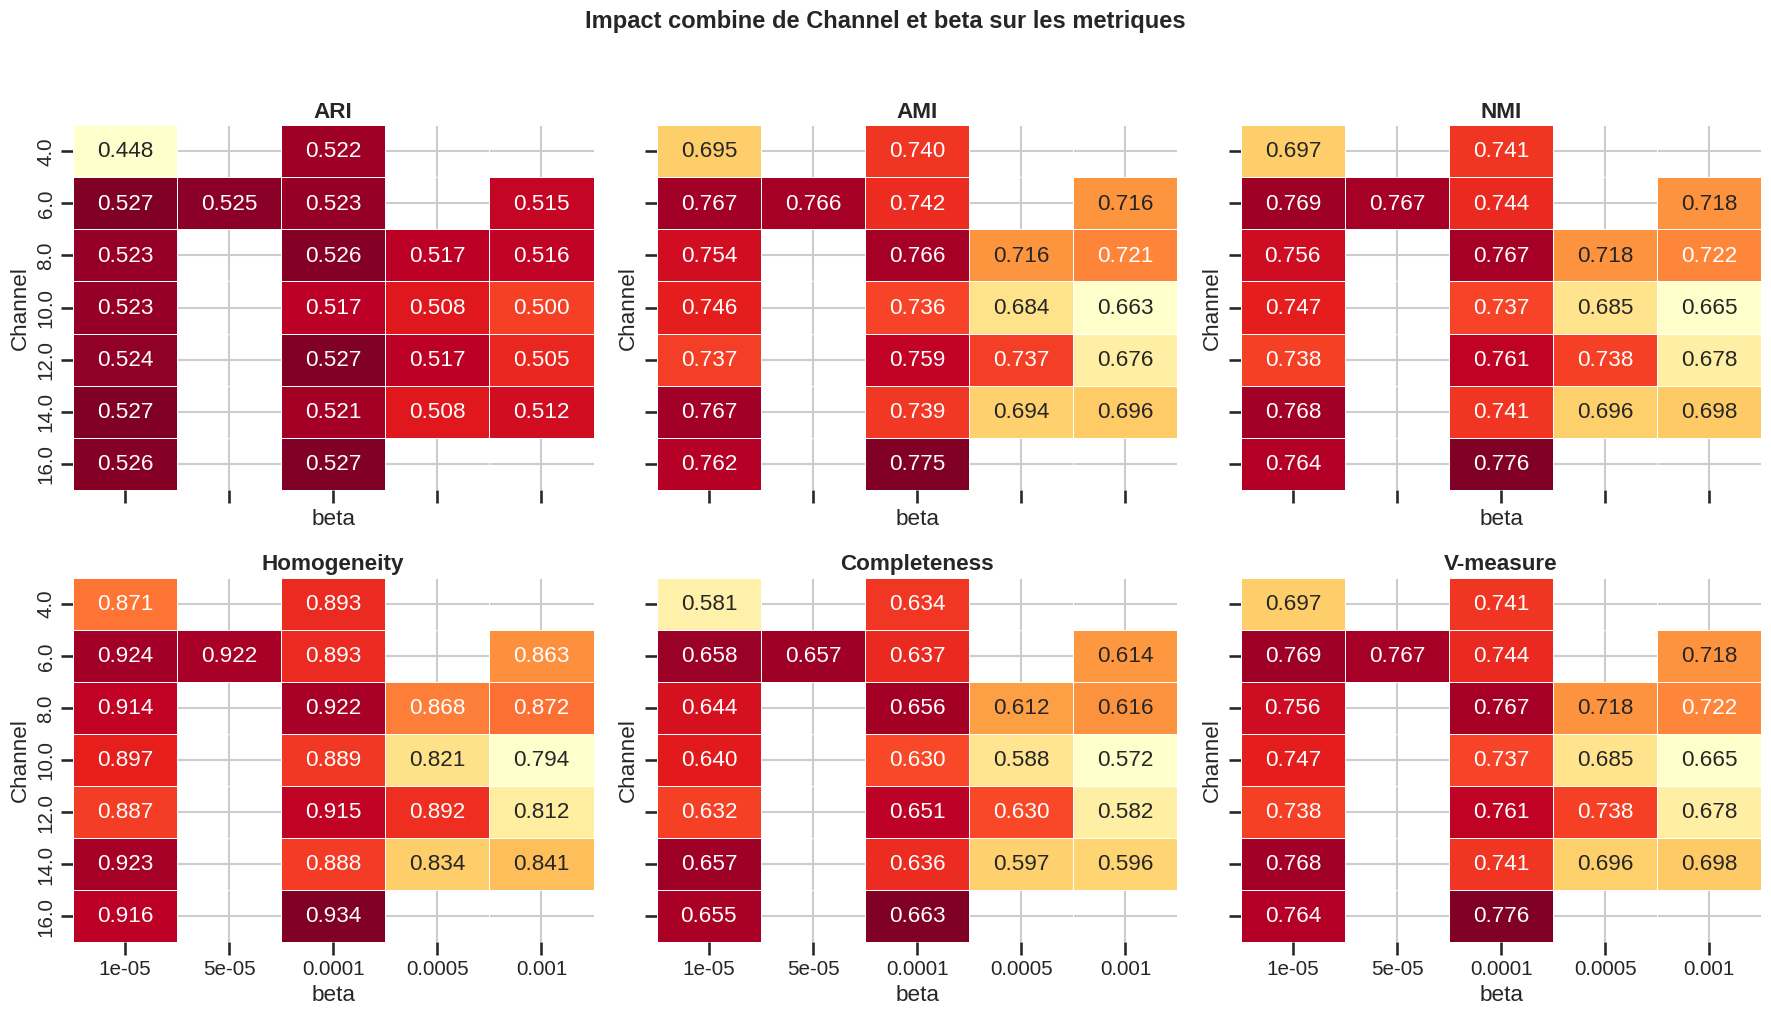

In [76]:
# Heatmaps Channel x beta pour chaque metrique
heat_source = df.groupby(['Channel', 'beta'])[METRIC_COLS].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, metric in zip(axes, METRIC_COLS):
    piv = heat_source.pivot(index='Channel', columns='beta', values=metric).sort_index()
    sns.heatmap(
        piv,
        ax=ax,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd',
        linewidths=0.4,
        cbar=False
    )
    ax.set_title(metric, weight='bold')
    ax.set_xlabel('beta')
    ax.set_ylabel('Channel')

plt.suptitle('Impact combine de Channel et beta sur les metriques', fontsize=17, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

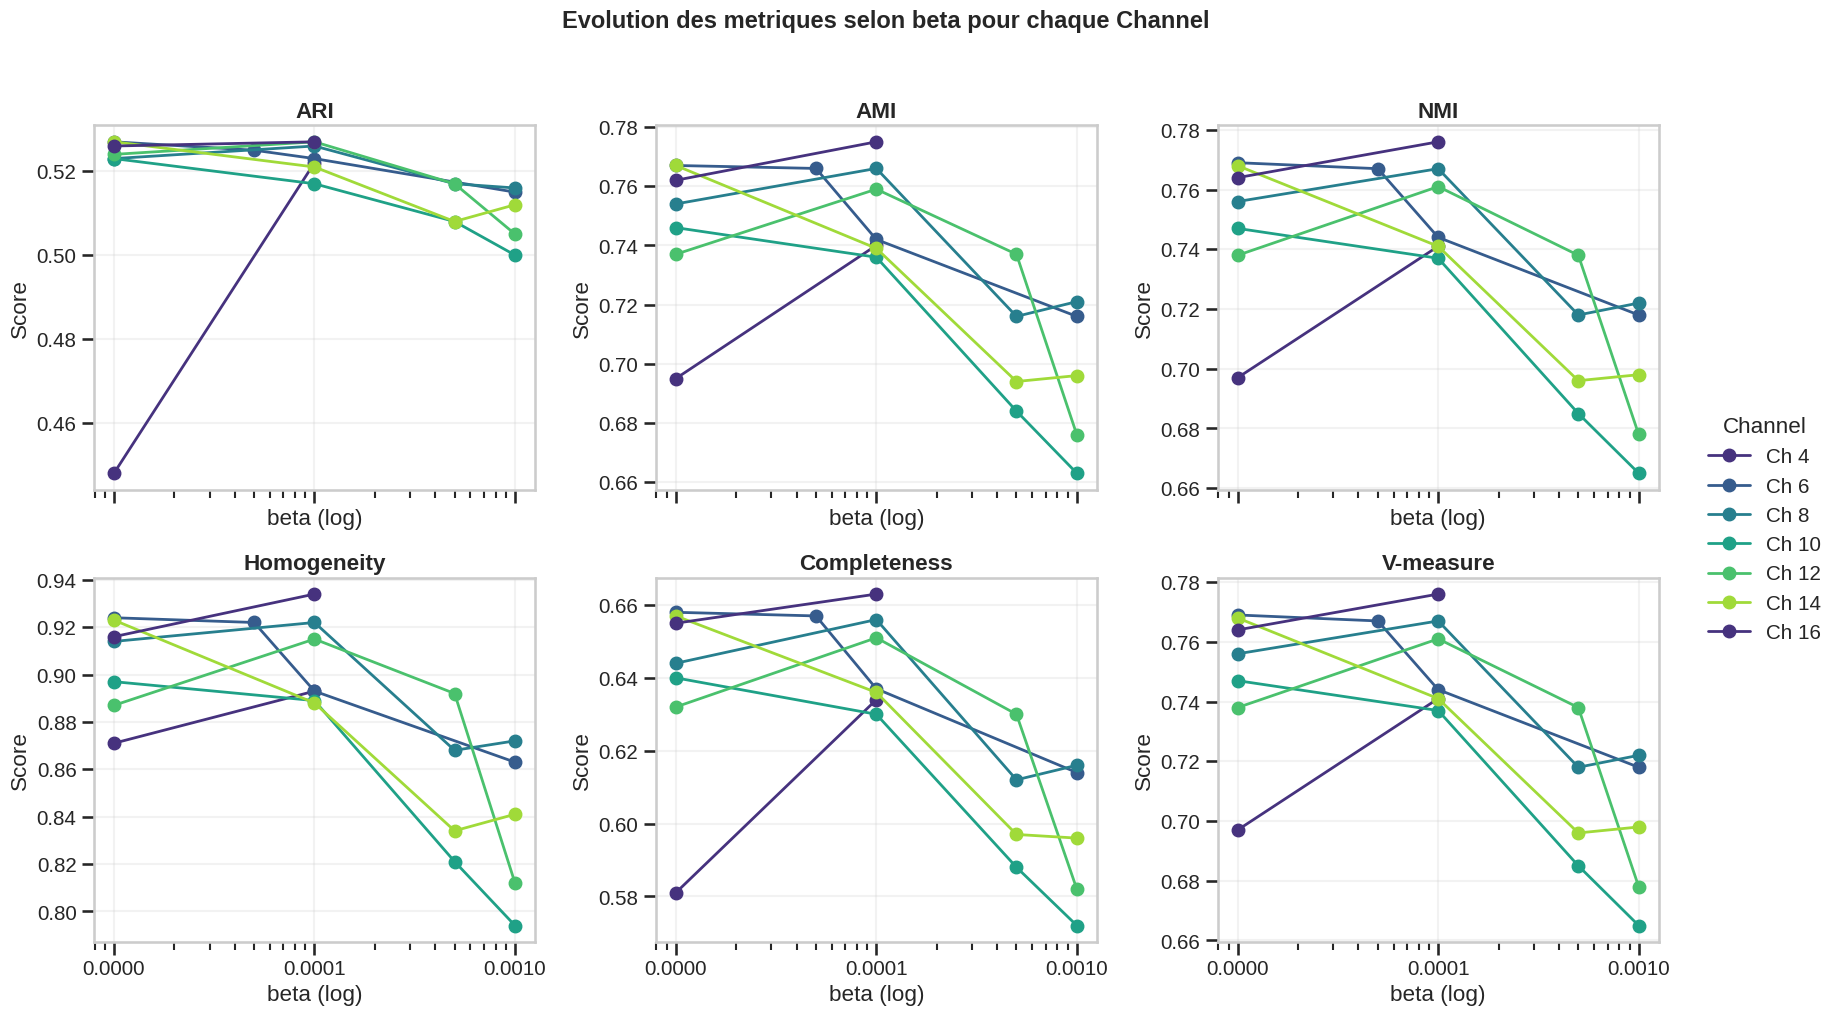

In [77]:
# Courbes metrique = f(beta), une ligne par Channel
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, METRIC_COLS):
    for ch, grp in df.sort_values('beta').groupby('Channel'):
        ax.plot(grp['beta'], grp[metric], marker='o', linewidth=2, label=f'Ch {int(ch)}')
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_title(metric, weight='bold')
    ax.set_xlabel('beta (log)')
    ax.set_ylabel('Score')
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Channel', loc='center right', bbox_to_anchor=(1.03, 0.5))
plt.suptitle('Evolution des metriques selon beta pour chaque Channel', fontsize=17, weight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

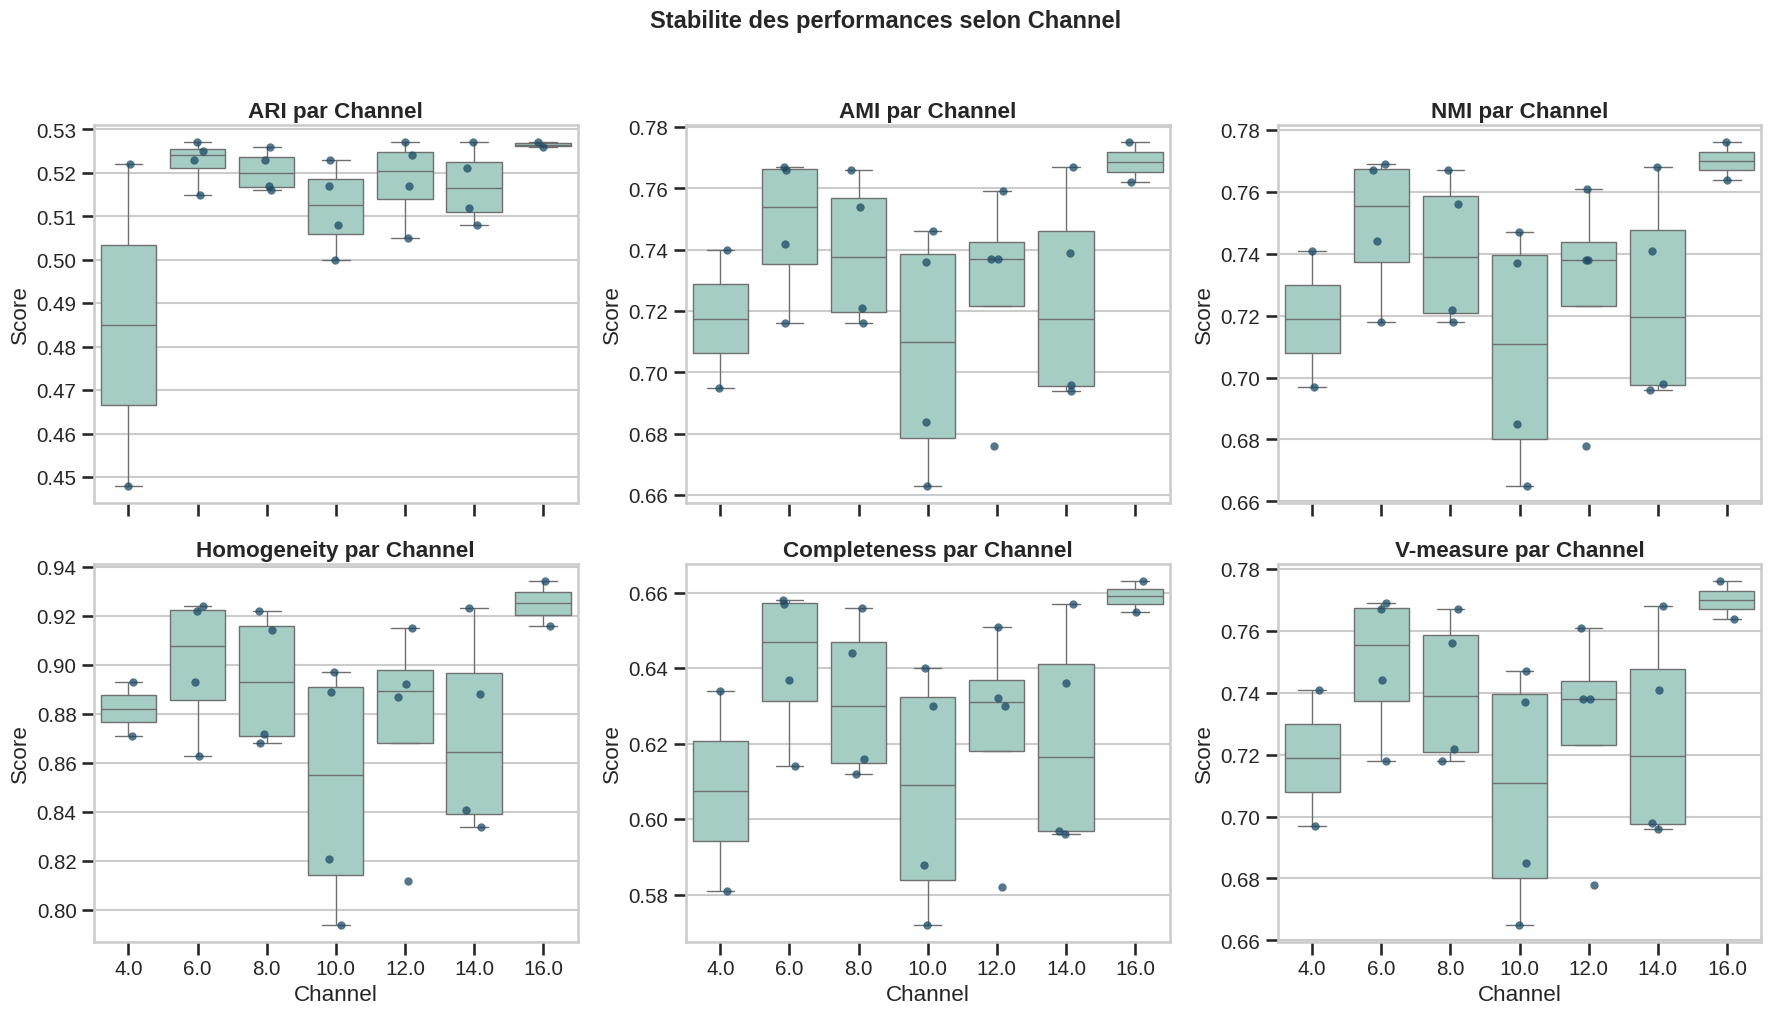

In [78]:
# Distribution des metriques par Channel (vision macro)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, METRIC_COLS):
    sns.boxplot(data=df, x='Channel', y=metric, ax=ax, color='#9fd3c7', fliersize=0)
    sns.stripplot(data=df, x='Channel', y=metric, ax=ax, color='#1b4965', alpha=0.75, size=6, jitter=0.12)
    ax.set_title(f'{metric} par Channel', weight='bold')
    ax.set_xlabel('Channel')
    ax.set_ylabel('Score')

plt.suptitle('Stabilite des performances selon Channel', fontsize=17, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

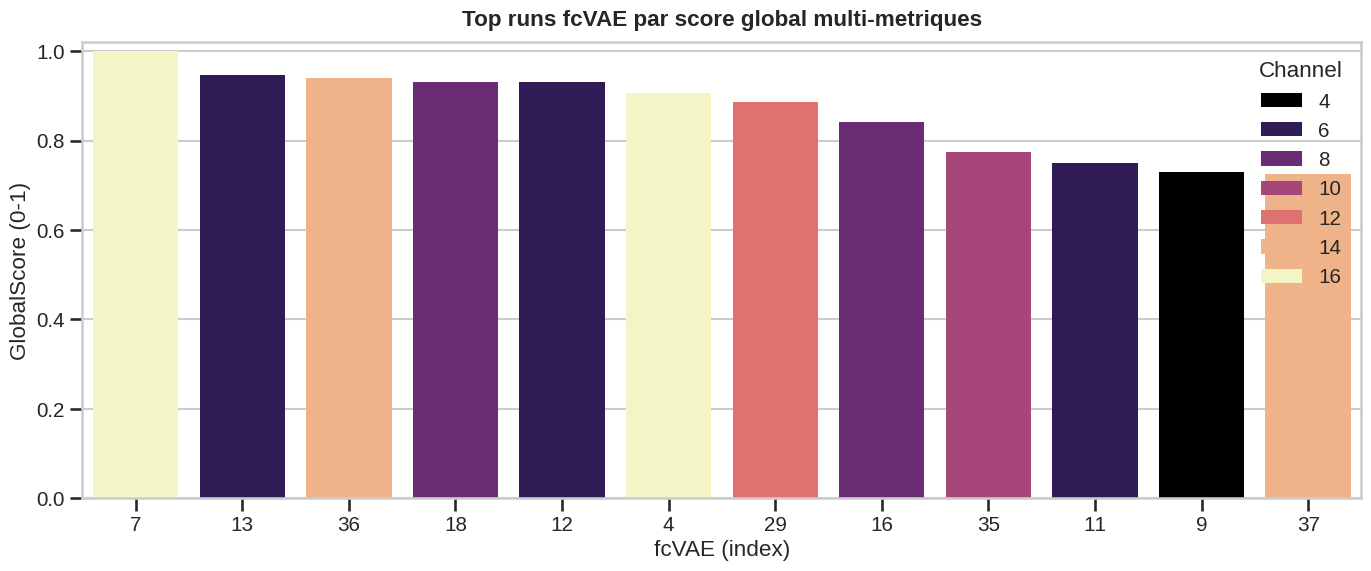

### Top 12 runs (fcVAE index)

,fcVAE,Channel,beta,GlobalScore,ARI,AMI,NMI,Homogeneity,Completeness,V-measure
fcVAE,,,,,,,,,,
7,7,16.0000,0.0001,1.0000,0.5270,0.7750,0.7760,0.9340,0.6630,0.7760
13,13,6.0000,0.0000,0.9460,0.5270,0.7670,0.7690,0.9240,0.6580,0.7690
36,36,14.0000,0.0000,0.9400,0.5270,0.7670,0.7680,0.9230,0.6570,0.7680
18,18,8.0000,0.0001,0.9304,0.5260,0.7660,0.7670,0.9220,0.6560,0.7670
12,12,6.0000,0.0001,0.9301,0.5250,0.7660,0.7670,0.9220,0.6570,0.7670
4,4,16.0000,0.0000,0.9064,0.5260,0.7620,0.7640,0.9160,0.6550,0.7640
29,29,12.0000,0.0001,0.8865,0.5270,0.7590,0.7610,0.9150,0.6510,0.7610
16,16,8.0000,0.0000,0.8416,0.5230,0.7540,0.7560,0.9140,0.6440,0.7560
35,35,10.0000,0.0000,0.7751,0.5230,0.7460,0.7470,0.8970,0.6400,0.7470


In [79]:
# Classement final: score global + detail par run (index fcVAE)
rank_df = df.copy()
for metric in METRIC_COLS:
    mmin, mmax = rank_df[metric].min(), rank_df[metric].max()
    rank_df[f'{metric}_norm'] = 0.0 if mmax == mmin else (rank_df[metric] - mmin) / (mmax - mmin)

rank_df['GlobalScore'] = rank_df[[f'{m}_norm' for m in METRIC_COLS]].mean(axis=1)
rank_df = rank_df.sort_values('GlobalScore', ascending=False)

top_runs = rank_df.head(12)

plt.figure(figsize=(14, 6))
sns.barplot(data=top_runs, x=top_runs.index.astype(str), y='GlobalScore', hue='Channel', dodge=False, palette='magma')
plt.title('Top runs fcVAE par score global multi-metriques', weight='bold', pad=12)
plt.xlabel('fcVAE (index)')
plt.ylabel('GlobalScore (0-1)')
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

display(Markdown('### Top 12 runs (fcVAE index)'))
display(top_runs[['fcVAE', 'Channel', 'beta', 'GlobalScore', *METRIC_COLS]])

In [80]:
display(Markdown('## Interpretation automatique orientee Channel et beta'))

channel_mean = df.groupby('Channel')[METRIC_COLS].mean()
beta_mean = df.groupby('beta')[METRIC_COLS].mean()

best_channel_global = channel_mean.mean(axis=1).idxmax()
best_beta_global = beta_mean.mean(axis=1).idxmax()
best_run = rank_df.iloc[0]

# Sensibilite moyenne au beta par channel
beta_sensitivity = (
    df.groupby('Channel')[METRIC_COLS]
    .agg(lambda s: s.max() - s.min())
    .mean(axis=1)
    .sort_values(ascending=False)
)

summary = f'''
### Resultats cles
- Meilleur run global (index fcVAE): **{int(best_run['fcVAE'])}**
  - Channel={int(best_run['Channel'])}, beta={best_run['beta']:.5f}, GlobalScore={best_run['GlobalScore']:.3f}
- Meilleur Channel en moyenne multi-metriques: **{int(best_channel_global)}**
- Meilleur beta en moyenne multi-metriques: **{best_beta_global:.5f}**
- Channel le plus sensible au choix de beta: **{int(beta_sensitivity.index[0])}** (plus grande variation moyenne).

### Lecture decisionnelle
- Si tu veux la meilleure performance globale: commencer par le meilleur run ci-dessus.
- Si tu veux un reglage robuste: privilegier le Channel moyen le plus stable sur plusieurs beta.
- Si tu optimises metric par metric: utiliser les courbes beta/log pour selectionner un beta specifique par Channel.
'''

display(Markdown(summary))

## Interpretation automatique orientee Channel et beta


### Resultats cles
- Meilleur run global (index fcVAE): **7**
  - Channel=16, beta=0.00010, GlobalScore=1.000
- Meilleur Channel en moyenne multi-metriques: **16**
- Meilleur beta en moyenne multi-metriques: **0.00005**
- Channel le plus sensible au choix de beta: **12** (plus grande variation moyenne).

### Lecture decisionnelle
- Si tu veux la meilleure performance globale: commencer par le meilleur run ci-dessus.
- Si tu veux un reglage robuste: privilegier le Channel moyen le plus stable sur plusieurs beta.
- Si tu optimises metric par metric: utiliser les courbes beta/log pour selectionner un beta specifique par Channel.


## Conclusion

> Ce notebook utilise maintenant `fcVAE` comme index de reference et concentre toute la comparaison sur l'effet de `Channel` et `beta`.

### Ce que tu peux faire ensuite
1. Figer une short-list de 3 combinaisons `(Channel, beta)` selon l'objectif metier.
2. Rejouer ces combinaisons sur plusieurs seeds pour mesurer la robustesse.
3. Ajouter des intervalles de confiance si tu as plusieurs repetitions par configuration.